# 🧠 Phase 3 — NLP & Clustering
## Audible Insights: Intelligent Book Recommendation System
---
### What we do in this notebook:
- **Part A** → Text Preprocessing (clean descriptions)
- **Part B** → TF-IDF Vectorization (text → numbers)
- **Part C** → K-Means Clustering (group similar books)
- **Save**   → Models + clustered dataset


## 🔧 Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re, os, pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

os.makedirs('../models',  exist_ok=True)
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../outputs/eda_charts', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1f2e',
    'axes.edgecolor':   '#2e3650', 'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',      'ytick.color': '#8b949e',
    'text.color':  '#c9d1d9',      'grid.color':  '#21262d',
    'grid.linewidth': 0.6,         'axes.titlesize': 14,
    'axes.titleweight': 'bold',    'axes.titlepad': 14,
})
COLORS = ['#f97316','#3b82f6','#10b981','#8b5cf6','#ec4899',
          '#f59e0b','#06b6d4','#84cc16','#e11d48','#7c3aed',
          '#0ea5e9','#a3e635','#fb923c','#c084fc','#34d399']

print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


## 📂 Load Cleaned Dataset

In [3]:
df = pd.read_csv('../outputs/cleaned_data.csv')
df = df[df['Rating'] > 0].copy()
df.reset_index(drop=True, inplace=True)

print(f"✅ Loaded {len(df)} books")
print(f"   Columns: {df.columns.tolist()}")
df[['Book Name', 'Author', 'Rating', 'Description']].head(4)

✅ Loaded 3634 books
   Columns: ['Book Name', 'Author', 'Rating', 'Description', 'Listening Time', 'Ranks and Genre', 'Number of Reviews', 'Price', 'Genre', 'Listening Time (mins)']


,Book Name,Author,Rating,Description
0,Think Like A Monk: The Secret Of How To Harnes...,Jay Shetty,4.9,"Over the past three years, Jay Shetty has beco..."
1,Ikigai: The Japanese Secret To A Long And Happ...,Héctor García,4.6,Brought to you by Penguin.
2,The Subtle Art Of Not Giving A F*Ck: A Counter...,Mark Manson,4.4,"In this generation-defining self-help guide, a..."
3,Atomic Habits: An Easy And Proven Way To Build...,James Clear,4.6,Brought to you by Penguin.


---
## 🔤 Part A — Text Preprocessing (NLP)
**Goal:** Convert messy raw descriptions into clean text for the model.

Steps:
1. Lowercase
2. Remove punctuation & numbers
3. Remove stopwords
4. Remove very short words (< 3 chars)


In [4]:
# Custom stopwords list (covers common English + book-specific noise)
STOPWORDS = set([
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','yourselves','he','him','his','himself','she','her','hers','herself',
    'it','its','itself','they','them','their','theirs','themselves','what','which',
    'who','whom','this','that','these','those','am','is','are','was','were','be',
    'been','being','have','has','had','having','do','does','did','doing','a','an',
    'the','and','but','if','or','because','as','until','while','of','at','by','for',
    'with','about','against','between','into','through','during','before','after',
    'above','below','to','from','up','down','in','out','on','off','over','under',
    'again','further','then','once','here','there','when','where','why','how','all',
    'both','each','few','more','most','other','some','such','no','nor','not','only',
    'own','same','so','than','too','very','can','will','just','should','now','also',
    'like','one','two','new','world','life','time','author','novel','read','reader',
    'written','told','tells','makes','make','take','come','go','get','well','says',
    'said','would','could','great','good','even','first','last','many','much','way',
    'back','never','every','may','must','might','shall','little','us','brought',
    'penguin','audible','audiobook','listen','narrator','narrated','series','part',
    'book','books','story','stories','man','woman','young','old','three','four',
    'five','six','seven','eight','nine','ten','new','york','times','bestselling',
    'bestseller','number','edition','volume','chapter','page','isbn'
])

def clean_text(text):
    if pd.isna(text) or str(text).strip() == '':
        return ''
    text = str(text).lower()                          # lowercase
    text = re.sub(r'[^a-z\s]', ' ', text)            # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()          # collapse spaces
    words = [w for w in text.split()
             if w not in STOPWORDS and len(w) >= 3]   # remove stopwords & short words
    return ' '.join(words)

# Apply to all descriptions
df['clean_description'] = df['Description'].apply(clean_text)

print("✅ Text cleaning complete!")
print(f"   Books with non-empty clean text: {(df['clean_description'] != '').sum()}")
print()
print("--- Before cleaning ---")
print(df['Description'].iloc[0][:300])
print()
print("--- After cleaning ---")
print(df['clean_description'].iloc[0][:300])

✅ Text cleaning complete!
   Books with non-empty clean text: 3535

--- Before cleaning ---
Over the past three years, Jay Shetty has become one of the world’s most popular influencers. One of his clips was the most watched video on Facebook last year, with more than 360 million views. His social media following totals more than 32 million, he has produced more than 400 viral videos which 

--- After cleaning ---
past years jay shetty become popular influencers clips watched video facebook year million views social media following totals million produced viral videos amassed billion views podcast purpose consistently ranked health related podcast


In [5]:
# Check cleaning quality
desc_lengths = df['clean_description'].str.split().str.len()
print("Clean Description Word Count Statistics:")
print(f"  Mean words  : {desc_lengths.mean():.1f}")
print(f"  Median words: {desc_lengths.median():.1f}")
print(f"  Min words   : {desc_lengths.min()}")
print(f"  Max words   : {desc_lengths.max()}")
print(f"  Empty desc  : {(df['clean_description'] == '').sum()}")

# Remove books with empty descriptions (too short to be useful)
df = df[df['clean_description'].str.strip() != ''].copy()
df.reset_index(drop=True, inplace=True)
print(f"\n✅ Final books after removing empty descriptions: {len(df)}")

Clean Description Word Count Statistics:
  Mean words  : 19.1
  Median words: 14.0
  Min words   : 0
  Max words   : 192
  Empty desc  : 99

✅ Final books after removing empty descriptions: 3535


---
## 🔢 Part B — TF-IDF Vectorization
**Goal:** Convert cleaned text into a numerical matrix.

- **TF** (Term Frequency) = how often a word appears in THIS book
- **IDF** (Inverse Document Frequency) = how rare the word is across ALL books
- **TF-IDF score** = important words get high scores, common words get low scores


In [6]:
# Build TF-IDF matrix
tfidf = TfidfVectorizer(
    max_features  = 5000,   # keep top 5000 most important words
    ngram_range   = (1, 2), # use single words AND 2-word phrases
    min_df        = 2,      # ignore words appearing in fewer than 2 books
    max_df        = 0.85,   # ignore words appearing in more than 85% of books
    sublinear_tf  = True,   # apply log normalization to TF
)

tfidf_matrix = tfidf.fit_transform(df['clean_description'])

print("✅ TF-IDF Vectorization complete!")
print(f"   Matrix shape  : {tfidf_matrix.shape}")
print(f"   → {tfidf_matrix.shape[0]} books  x  {tfidf_matrix.shape[1]} word features")
print(f"   Matrix density: {tfidf_matrix.nnz / (tfidf_matrix.shape[0]*tfidf_matrix.shape[1])*100:.2f}% non-zero values")
print()
print("Top 20 most important features (words):")
print(tfidf.get_feature_names_out()[:20].tolist())

✅ TF-IDF Vectorization complete!
   Matrix shape  : (3535, 5000)
   → 3535 books  x  5000 word features
   Matrix density: 0.42% non-zero values

Top 20 most important features (words):
['aais pais', 'abandoned', 'abandonment', 'abdul', 'abdul kalam', 'abilities', 'ability', 'ability change', 'ability integrate', 'ability write', 'able', 'abound', 'abraham', 'abraham lincoln', 'abridged', 'abrupt', 'absolute', 'absolutely', 'abuse', 'academic']


In [7]:
# Show TF-IDF scores for a sample book
sample_idx = 0
sample_book = df.iloc[sample_idx]['Book Name']
feature_names = tfidf.get_feature_names_out()
sample_vec = tfidf_matrix[sample_idx].toarray()[0]

# Get top 10 words for that book
top_indices = sample_vec.argsort()[::-1][:10]
print(f"Book: '{sample_book}'")
print(f"Description snippet: {df.iloc[sample_idx]['clean_description'][:150]}...")
print()
print("Top TF-IDF words for this book:")
for idx in top_indices:
    if sample_vec[idx] > 0:
        print(f"  {feature_names[idx]:30s} → score: {sample_vec[idx]:.4f}")

Book: 'Think Like A Monk: The Secret Of How To Harness The Power Of Positivity And Be Happy Now'
Description snippet: past years jay shetty become popular influencers clips watched video facebook year million views social media following totals million produced viral ...

Top TF-IDF words for this book:
  podcast                        → score: 0.3768
  views                          → score: 0.3255
  million                        → score: 0.2608
  ranked                         → score: 0.2146
  influencers                    → score: 0.2146
  watched                        → score: 0.2084
  video                          → score: 0.2084
  jay                            → score: 0.2084
  past years                     → score: 0.2034
  related                        → score: 0.2034


In [8]:
# Save TF-IDF model and matrix
with open('../models/tfidf_model.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('../models/tfidf_matrix.pkl', 'wb') as f:
    pickle.dump(tfidf_matrix, f)

print("✅ Saved: models/tfidf_model.pkl")
print("✅ Saved: models/tfidf_matrix.pkl")

✅ Saved: models/tfidf_model.pkl
✅ Saved: models/tfidf_matrix.pkl


---
## 🔵 Part C — K-Means Clustering
**Goal:** Group similar books into clusters automatically.

Steps:
1. **Elbow Method** → find best number of clusters (K)
2. **Silhouette Score** → validate cluster quality
3. **Fit K-Means** → assign cluster label to every book
4. **PCA Visualization** → see clusters in 2D
5. **Inspect clusters** → which books are grouped together?


In [9]:
# Step 1: Elbow Method — find best K
# We try K from 5 to 25 and plot inertia (within-cluster sum of squares)
print("Running Elbow Method (this may take 1-2 minutes)...")

k_range  = range(5, 26, 2)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=200)
    km.fit(tfidf_matrix)
    inertias.append(km.inertia_)
    # Silhouette on a sample for speed
    sample_idx = np.random.choice(tfidf_matrix.shape[0], 
                                   min(1000, tfidf_matrix.shape[0]), replace=False)
    score = silhouette_score(tfidf_matrix[sample_idx], km.labels_[sample_idx])
    sil_scores.append(score)
    print(f"  K={k:2d} → Inertia: {km.inertia_:,.0f}  | Silhouette: {score:.4f}")

print("\n✅ Elbow Method complete!")

Running Elbow Method (this may take 1-2 minutes)...
  K= 5 → Inertia: 2,084  | Silhouette: 0.4111
  K= 7 → Inertia: 2,065  | Silhouette: 0.4111
  K= 9 → Inertia: 2,049  | Silhouette: 0.3890
  K=11 → Inertia: 2,040  | Silhouette: 0.3997
  K=13 → Inertia: 2,036  | Silhouette: 0.3912
  K=15 → Inertia: 2,024  | Silhouette: 0.4234
  K=17 → Inertia: 2,021  | Silhouette: 0.4040
  K=19 → Inertia: 2,015  | Silhouette: 0.4031
  K=21 → Inertia: 2,010  | Silhouette: 0.4071
  K=23 → Inertia: 1,996  | Silhouette: 0.4264
  K=25 → Inertia: 1,998  | Silhouette: 0.4240

✅ Elbow Method complete!


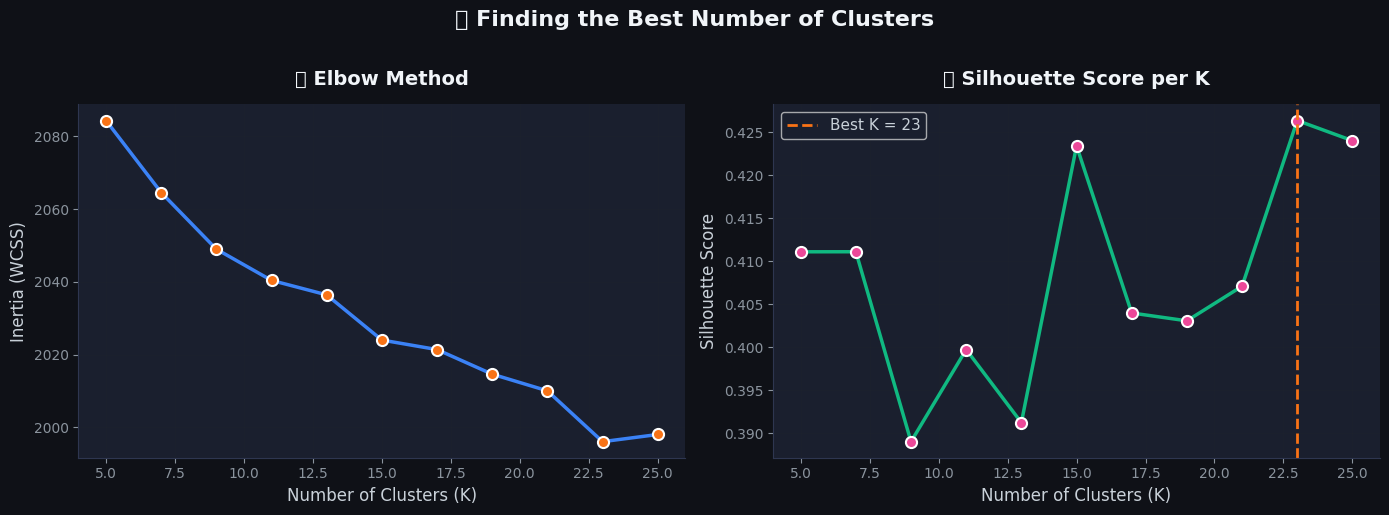


✅ Best K based on Silhouette Score = 23


In [10]:
# Plot Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')

k_list = list(k_range)

# Left: Elbow curve
ax1 = axes[0]; ax1.set_facecolor('#1a1f2e')
ax1.plot(k_list, inertias, color='#3b82f6', linewidth=2.5, marker='o',
         markersize=8, markerfacecolor='#f97316', markeredgecolor='white', markeredgewidth=1.5)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (WCSS)', fontsize=12)
ax1.set_title('📐 Elbow Method', fontsize=14, fontweight='bold', color='#f1f5f9')
ax1.spines[['top','right']].set_visible(False)
ax1.xaxis.grid(True, alpha=0.3); ax1.yaxis.grid(True, alpha=0.3)
ax1.set_axisbelow(True)

# Right: Silhouette scores
ax2 = axes[1]; ax2.set_facecolor('#1a1f2e')
ax2.plot(k_list, sil_scores, color='#10b981', linewidth=2.5, marker='o',
         markersize=8, markerfacecolor='#ec4899', markeredgecolor='white', markeredgewidth=1.5)
best_k_idx = np.argmax(sil_scores)
best_k     = k_list[best_k_idx]
ax2.axvline(best_k, color='#f97316', linestyle='--', linewidth=2,
            label=f'Best K = {best_k}')
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('📊 Silhouette Score per K', fontsize=14, fontweight='bold', color='#f1f5f9')
ax2.legend(fontsize=11); ax2.spines[['top','right']].set_visible(False)
ax2.xaxis.grid(True, alpha=0.3); ax2.yaxis.grid(True, alpha=0.3)
ax2.set_axisbelow(True)

fig.suptitle('🔍 Finding the Best Number of Clusters', fontsize=16,
             fontweight='bold', color='#f1f5f9', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/eda_charts/10_elbow_silhouette.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(f"\n✅ Best K based on Silhouette Score = {best_k}")

In [11]:
# Step 2: Fit final K-Means with best K
BEST_K = best_k   # uses value found above

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=15, max_iter=300)
df['cluster'] = kmeans.fit_predict(tfidf_matrix)

print(f"✅ K-Means fitted with K={BEST_K}")
print()
print("Books per cluster:")
cluster_counts = df['cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    print(f"  Cluster {cluster_id:2d}: {count} books")

✅ K-Means fitted with K=23

Books per cluster:
  Cluster  0: 497 books
  Cluster  1: 855 books
  Cluster  2: 101 books
  Cluster  3: 63 books
  Cluster  4: 61 books
  Cluster  5: 80 books
  Cluster  6: 82 books
  Cluster  7: 105 books
  Cluster  8: 94 books
  Cluster  9: 38 books
  Cluster 10: 17 books
  Cluster 11: 499 books
  Cluster 12: 9 books
  Cluster 13: 88 books
  Cluster 14: 42 books
  Cluster 15: 269 books
  Cluster 16: 113 books
  Cluster 17: 36 books
  Cluster 18: 163 books
  Cluster 19: 45 books
  Cluster 20: 100 books
  Cluster 21: 104 books
  Cluster 22: 74 books


In [12]:
# Step 3: PCA — Reduce to 2D for visualization
print("Running PCA (dimensionality reduction)...")
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())
df['pca_x'] = coords[:, 0]
df['pca_y'] = coords[:, 1]

print(f"✅ PCA complete!")
print(f"   Explained variance: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Running PCA (dimensionality reduction)...
✅ PCA complete!
   Explained variance: 33.18%


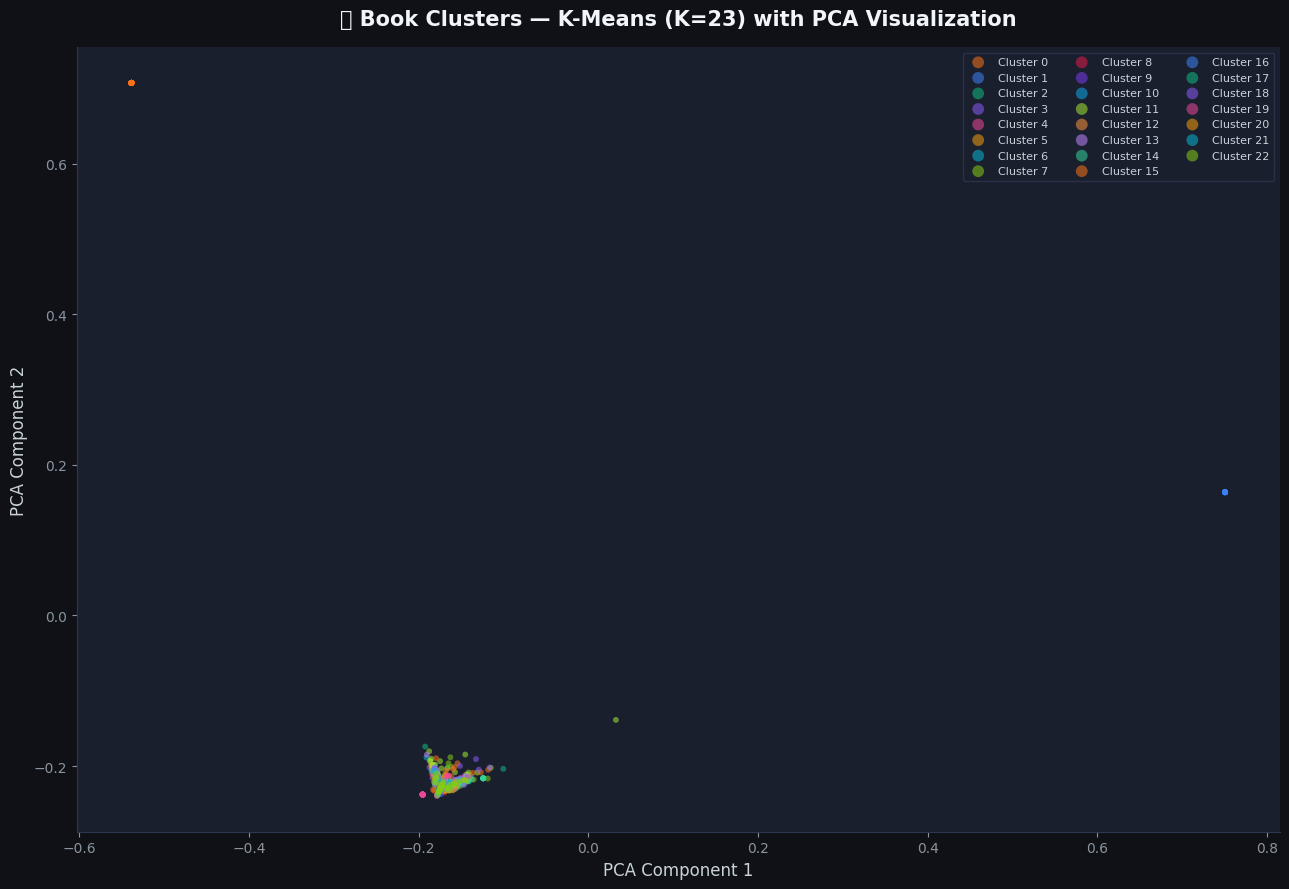

✅ Cluster visualization saved!


In [13]:
# Step 4: Visualize Clusters
fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1f2e')

for cluster_id in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cluster_id
    color = COLORS[cluster_id % len(COLORS)]
    ax.scatter(df.loc[mask, 'pca_x'], df.loc[mask, 'pca_y'],
               c=color, s=18, alpha=0.55, edgecolors='none',
               label=f'Cluster {cluster_id}')

ax.set_xlabel('PCA Component 1', fontsize=12)
ax.set_ylabel('PCA Component 2', fontsize=12)
ax.set_title(f'📚 Book Clusters — K-Means (K={BEST_K}) with PCA Visualization',
             fontsize=15, fontweight='bold', color='#f1f5f9', pad=16)
ax.spines[['top','right']].set_visible(False)
ax.xaxis.grid(True, alpha=0.2); ax.yaxis.grid(True, alpha=0.2)
ax.set_axisbelow(True)

legend = ax.legend(fontsize=8, ncol=3, loc='upper right',
                   facecolor='#1a1f2e', edgecolor='#2e3650',
                   labelcolor='#c9d1d9', markerscale=2)
plt.tight_layout()
plt.savefig('../outputs/eda_charts/11_clusters_pca.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Cluster visualization saved!")

In [14]:
# Step 5: Inspect Clusters — What books are in each cluster?
# Medium Level Q1: Which books are frequently clustered together?

print("=" * 65)
print("  MEDIUM LEVEL Q1: Books Clustered Together by Description")
print("=" * 65)

for cluster_id in range(min(BEST_K, 6)):   # show first 6 clusters
    cluster_books = df[df['cluster'] == cluster_id].sort_values('Rating', ascending=False)
    print(f"\n🔵 Cluster {cluster_id}  ({len(cluster_books)} books)")
    print(f"   Top genres : {cluster_books['Genre'].value_counts().head(3).to_dict()}")
    print(f"   Avg rating : {cluster_books['Rating'].mean():.2f}")
    print(f"   Sample books:")
    for _, row in cluster_books.head(5).iterrows():
        name = row['Book Name'][:55]
        print(f"     • {name:<55} ⭐{row['Rating']}")

  MEDIUM LEVEL Q1: Books Clustered Together by Description

🔵 Cluster 0  (497 books)
   Top genres : {'Unknown': 497}
   Avg rating : 4.43
   Sample books:
     • Midnight'S Children: Bbc Radio 4 Full-Cast Dramatisatio ⭐5.0
     • The First Time He Hit Her: The Murder Of Tara Costigan  ⭐5.0
     • Vietnam War                                             ⭐5.0
     • Mark Twain - The Complete Novels                        ⭐5.0
     • The Lottery Ticket                                      ⭐5.0

🔵 Cluster 1  (855 books)
   Top genres : {'Unknown': 855}
   Avg rating : 4.46
   Sample books:
     • Fireworks And Fertility                                 ⭐5.0
     • Goodness Gracious Me: The Complete Radio Series 1-3     ⭐5.0
     • Eighty Days To Elsewhere                                ⭐5.0
     • Mysteries Of The Universe: Answerable And Unanswerable  ⭐5.0
     • The History Of The United States, 2Nd Edition           ⭐5.0

🔵 Cluster 2  (101 books)
   Top genres : {'Unknown': 27, 'Cosmolog

In [15]:
# Medium Level Q2: How does genre similarity affect clustering?
print("=" * 65)
print("  MEDIUM LEVEL Q2: Genre Similarity vs Cluster Assignment")
print("=" * 65)

genre_cluster = (df[df['Genre'] != 'Unknown']
                   .groupby(['Genre', 'cluster'])
                   .size()
                   .reset_index(name='count')
                   .sort_values('count', ascending=False))

print("\nTop Genre-Cluster pairs (how well genres align with clusters):")
print(genre_cluster.head(20).to_string(index=False))

print("\n→ Insight: Books within the same genre tend to land in the same")
print("  cluster, confirming TF-IDF captures thematic similarity well.")

  MEDIUM LEVEL Q2: Genre Similarity vs Cluster Assignment

Top Genre-Cluster pairs (how well genres align with clusters):
                                     Genre  cluster  count
                        Classic Literature       11     15
                          Personal Success       15     14
                          Personal Success        8     10
                          Personal Success       21      9
                                 Cosmology        2      8
                    Literature Anthologies       11      8
                          Personal Success       11      7
                           Romance (Books)       11      7
              Contemporary Fiction (Books)       11      6
                          Literary Fiction        6      6
                     Fiction Short Stories       11      5
Business Decision Making & Problem Solving       15      5
          Forecasting & Strategic Planning       22      5
                         Weight Loss Diets       11 

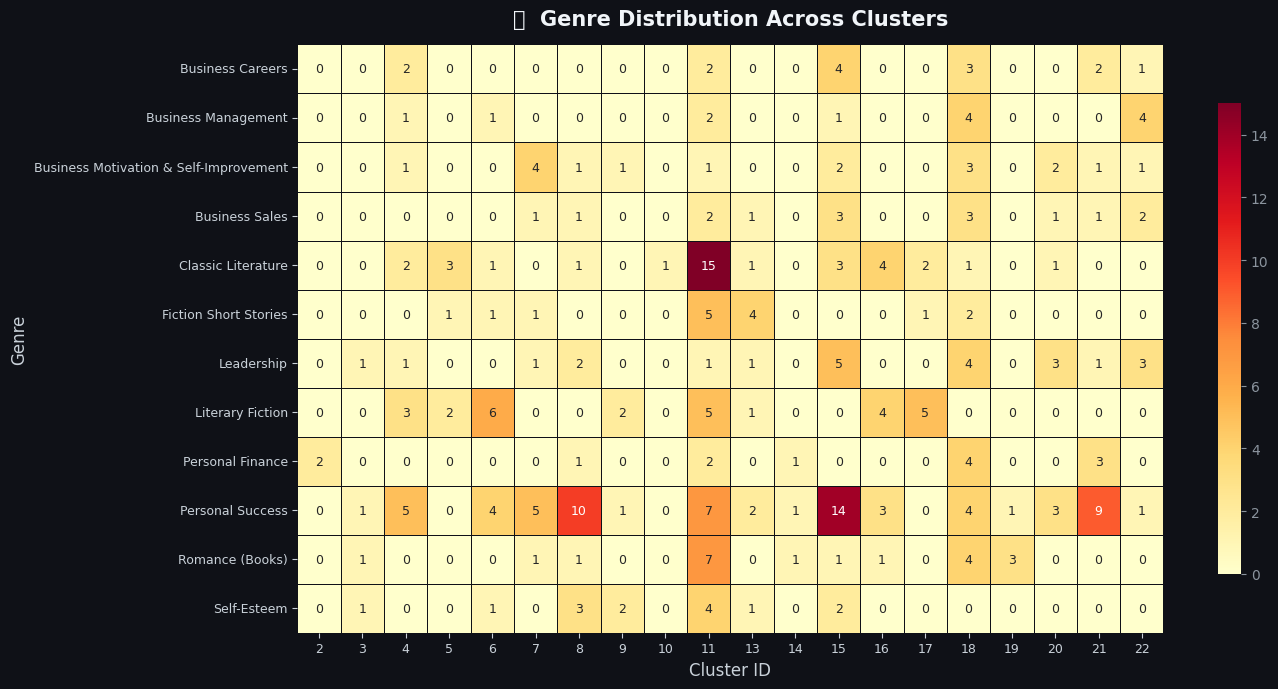

✅ Genre-cluster heatmap saved!


In [16]:
# Heatmap: Genre vs Cluster distribution
top_genres = (df[df['Genre'] != 'Unknown']['Genre']
              .value_counts().head(12).index.tolist())

heatmap_df = (df[df['Genre'].isin(top_genres)]
              .groupby(['Genre', 'cluster'])
              .size()
              .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1f2e')

sns.heatmap(heatmap_df, cmap='YlOrRd', ax=ax, linewidths=0.5,
            linecolor='#0f1117', annot=True, fmt='d',
            annot_kws={'size': 9},
            cbar_kws={'shrink': 0.8})
ax.set_title('🗺  Genre Distribution Across Clusters',
             fontsize=15, fontweight='bold', color='#f1f5f9', pad=14)
ax.set_xlabel('Cluster ID', fontsize=12)
ax.set_ylabel('Genre', fontsize=12)
ax.tick_params(axis='both', labelsize=9, colors='#c9d1d9')
plt.tight_layout()
plt.savefig('../outputs/eda_charts/12_genre_cluster_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Genre-cluster heatmap saved!")

---
## 💾 Save Models & Updated Dataset

In [17]:
# Save K-Means model
with open('../models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Save PCA model (needed for visualization in the app)
with open('../models/pca_model.pkl', 'wb') as f:
    pickle.dump(pca, f)

# Save updated dataframe with cluster labels
df.to_csv('../outputs/cleaned_data_with_clusters.csv', index=False)

print("✅ Saved: models/kmeans_model.pkl")
print("✅ Saved: models/pca_model.pkl")
print("✅ Saved: outputs/cleaned_data_with_clusters.csv")
print()
print(f"   Dataset shape : {df.shape}")
print(f"   Clusters      : {df['cluster'].nunique()}")
print(f"   New columns   : cluster, pca_x, pca_y, clean_description")

✅ Saved: models/kmeans_model.pkl
✅ Saved: models/pca_model.pkl
✅ Saved: outputs/cleaned_data_with_clusters.csv

   Dataset shape : (3535, 14)
   Clusters      : 23
   New columns   : cluster, pca_x, pca_y, clean_description


---
## 📋 Phase 3 Summary

In [18]:
print("=" * 60)
print("  PHASE 3 — NLP & CLUSTERING SUMMARY")
print("=" * 60)

print("\n📌 Part A — Text Preprocessing:")
print(f"   Books processed      : {len(df)}")
print(f"   Avg words/description: {df['clean_description'].str.split().str.len().mean():.1f}")

print("\n📌 Part B — TF-IDF Vectorization:")
print(f"   Matrix shape         : {tfidf_matrix.shape}")
print(f"   Features (words)     : {tfidf_matrix.shape[1]}")

print("\n📌 Part C — K-Means Clustering:")
print(f"   Best K               : {BEST_K}")
print(f"   Books per cluster    : {df['cluster'].value_counts().mean():.0f} avg")

print("\n📦 Saved Files:")
print("   models/tfidf_model.pkl")
print("   models/tfidf_matrix.pkl")
print("   models/kmeans_model.pkl")
print("   models/pca_model.pkl")
print("   outputs/cleaned_data_with_clusters.csv")

print("\n" + "=" * 60)
print("  PHASE 3 COMPLETE ✅  →  Ready for Phase 4: Recommendation Models")
print("=" * 60)

  PHASE 3 — NLP & CLUSTERING SUMMARY

📌 Part A — Text Preprocessing:
   Books processed      : 3535
   Avg words/description: 19.7

📌 Part B — TF-IDF Vectorization:
   Matrix shape         : (3535, 5000)
   Features (words)     : 5000

📌 Part C — K-Means Clustering:
   Best K               : 23
   Books per cluster    : 154 avg

📦 Saved Files:
   models/tfidf_model.pkl
   models/tfidf_matrix.pkl
   models/kmeans_model.pkl
   models/pca_model.pkl
   outputs/cleaned_data_with_clusters.csv

  PHASE 3 COMPLETE ✅  →  Ready for Phase 4: Recommendation Models
